In [32]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# --- Чтение Excel ---
RAW_PATH = "/Users/sabina/mosstat_dashboard/data/raw/health_diseases.xlsx"
df = pd.read_excel(RAW_PATH, skiprows=3)  # при необходимости подкорректируйте skiprows


In [34]:
# --- Предобработка ---
# Переименовываем первый столбец в disease
df = df.rename(columns={df.columns[0]: "disease"})



In [35]:
# Убираем пустые строки
df = df.dropna(subset=["disease"])

# Преобразуем таблицу в длинный формат для удобной визуализации
df_long = df.melt(id_vars=["disease"], var_name="year", value_name="cases")



In [36]:
# Приводим значения к числовому типу
df_long["cases"] = (
    df_long["cases"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace(r"[^\d\.]", "", regex=True)
)
df_long["cases"] = pd.to_numeric(df_long["cases"], errors="coerce")



In [37]:
# Убираем пропуски после конверсии
df_long = df_long.dropna(subset=["cases"])



In [38]:
# Приводим год к целому числу
df_long["year"] = df_long["year"].astype(int)



In [39]:
# --- Сохраняем очищенные данные ---
df_long.to_csv('/Users/sabina/mosstat_dashboard/data/processed/health_diseases_cleaned.csv', index=False)
print("Данные предобработаны и сохранены")



Данные предобработаны и сохранены


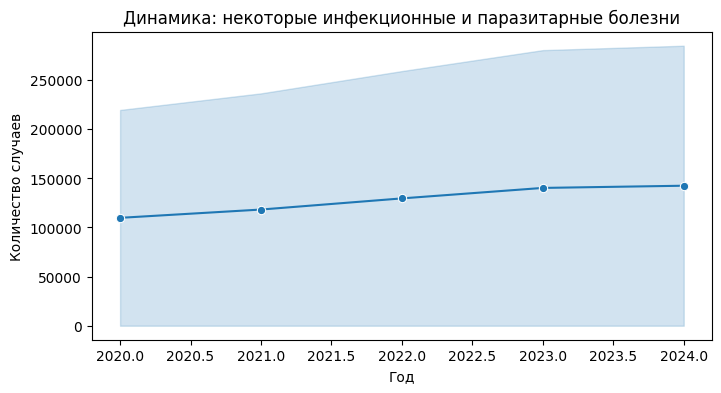

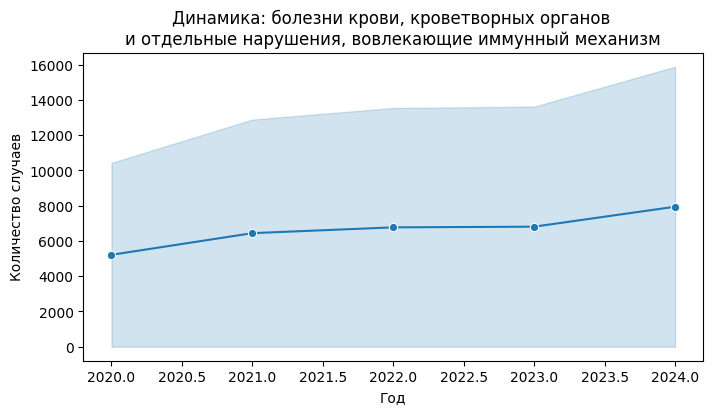

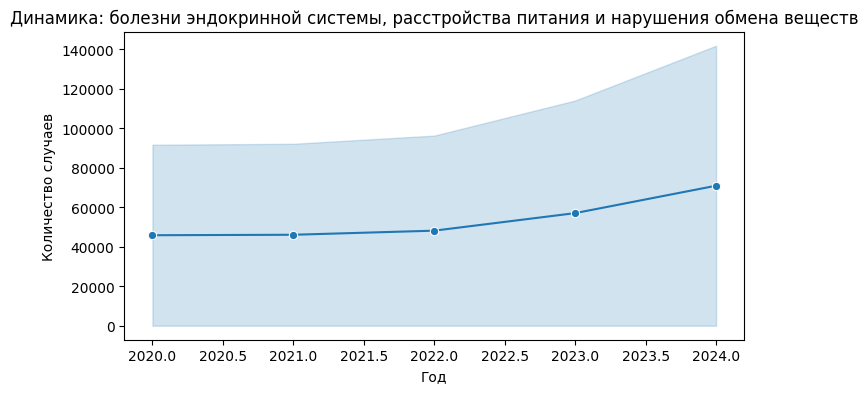

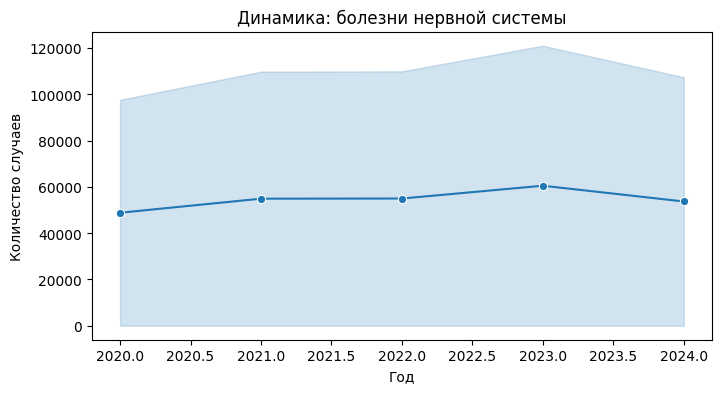

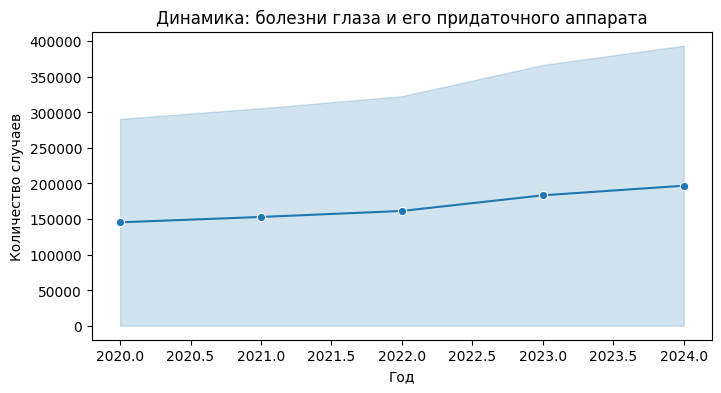

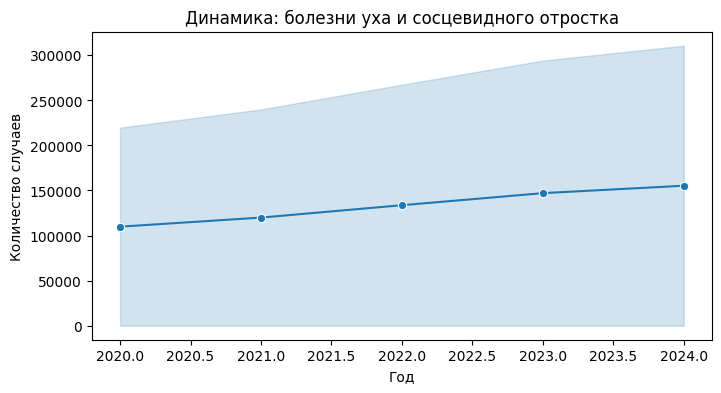

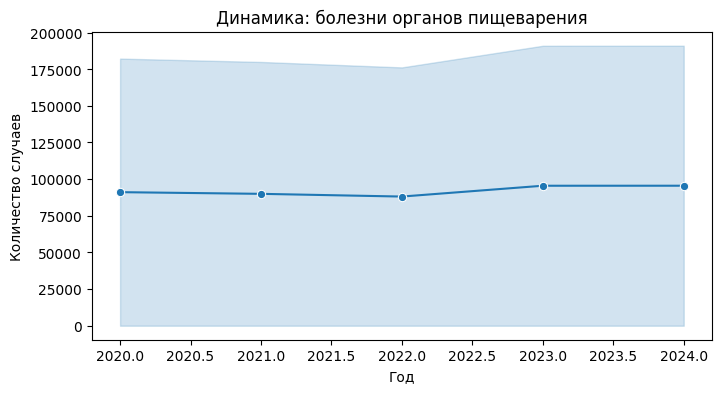

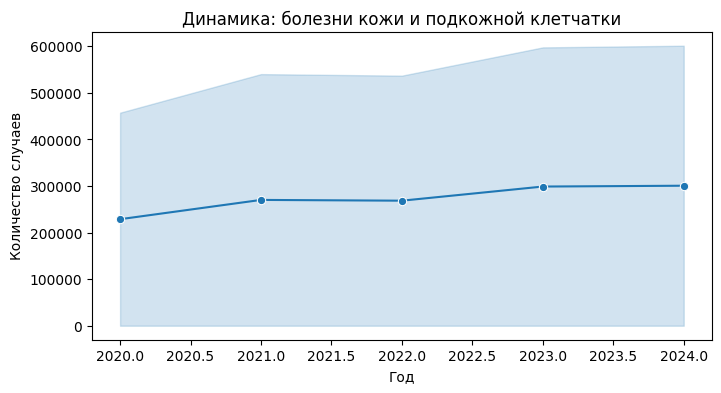

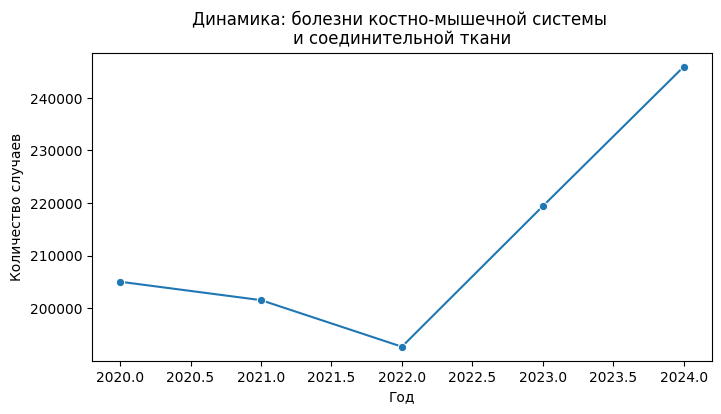

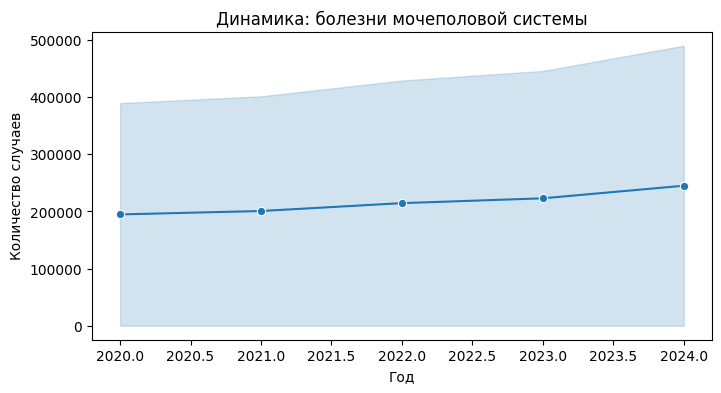

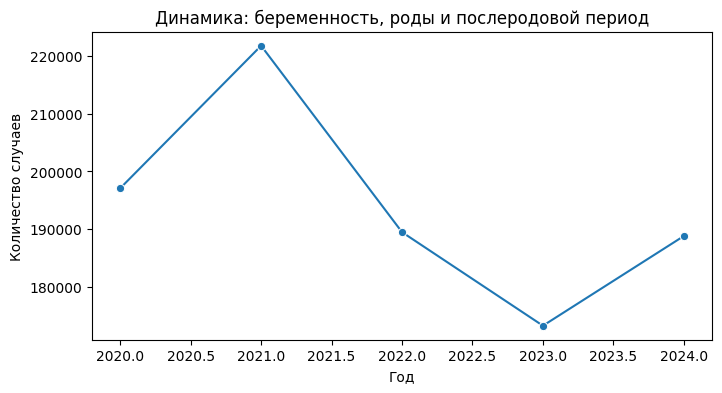

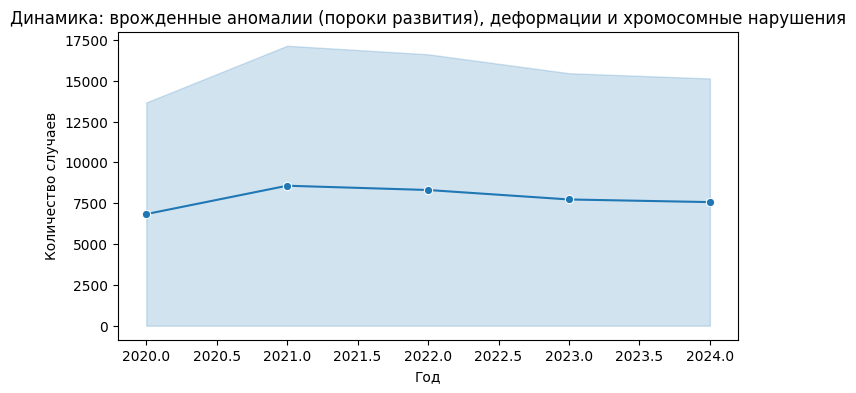

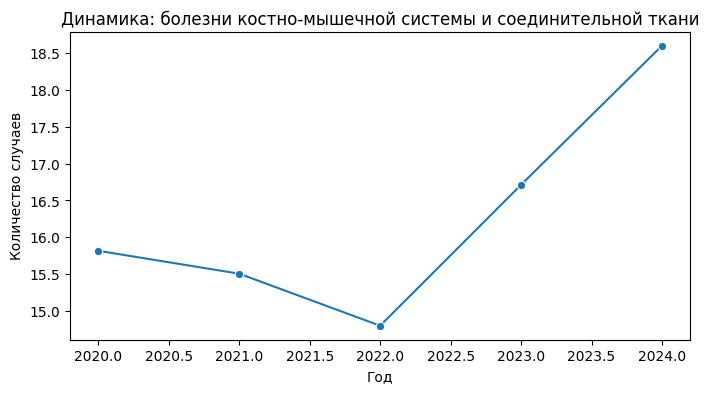

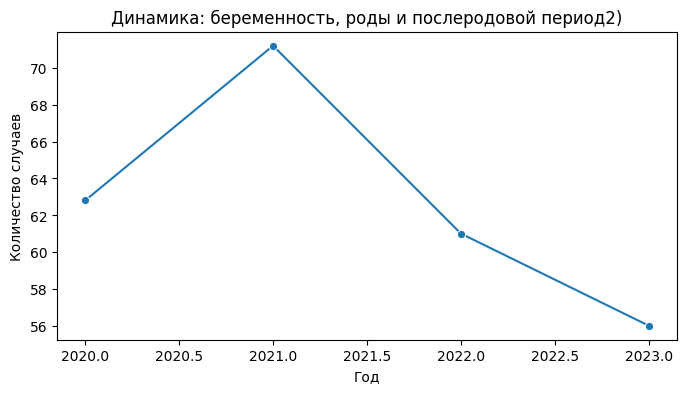

In [40]:
# --- 3. Отдельные графики для мелких групп ---
small_diseases = df_long[~df_long["disease"].isin(major_diseases)]["disease"].unique()
for disease in small_diseases:
    plt.figure(figsize=(8,4))
    subset = df_long[df_long["disease"] == disease]
    sns.lineplot(data=subset, x='year', y='cases', marker='o')
    plt.title(f"Динамика: {disease}")
    plt.xlabel("Год")
    plt.ylabel("Количество случаев")
    plt.show()

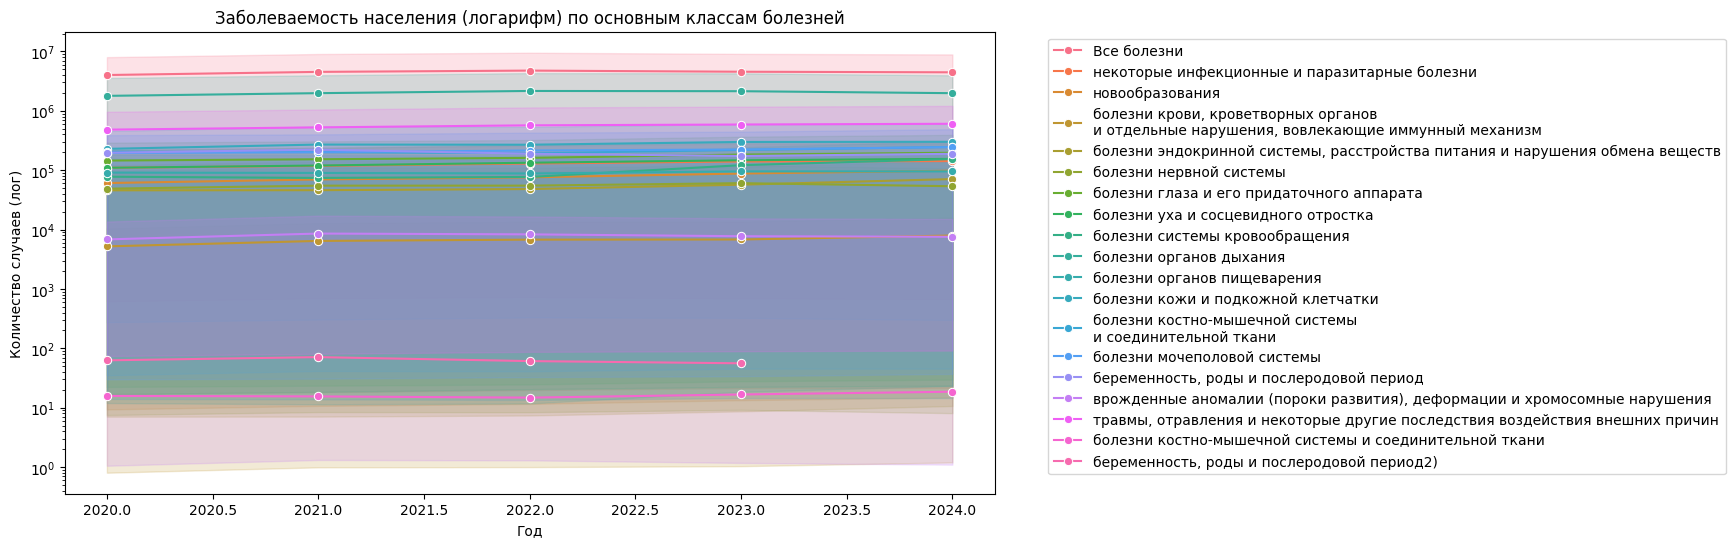

In [41]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_long, x='year', y='cases', hue='disease', marker='o')
plt.yscale("log")
plt.title("Заболеваемость населения (логарифм) по основным классам болезней")
plt.xlabel("Год")
plt.ylabel("Количество случаев (лог)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [42]:

# --- 1. Динамика ключевых категорий ---
major_diseases = [
    "Все болезни",
    "болезни органов дыхания",
    "травмы, отравления и некоторые другие последствия воздействия внешних причин",
    "новообразования",
    "болезни системы кровообращения"
]



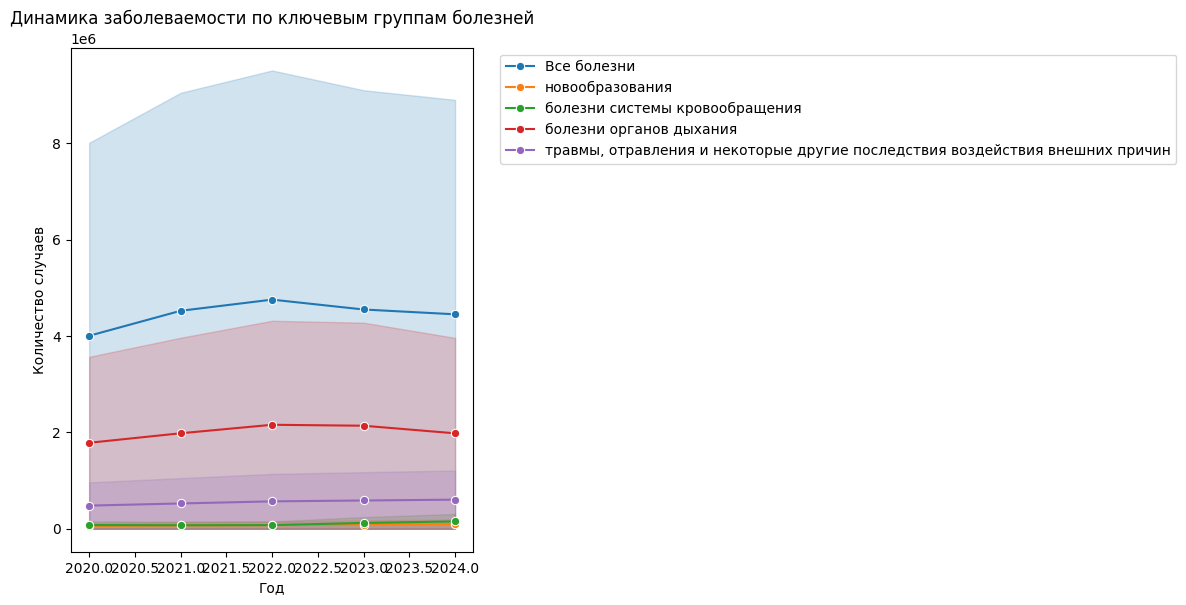

In [43]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_long[df_long["disease"].isin(major_diseases)],
             x='year', y='cases', hue='disease', marker='o')
plt.title("Динамика заболеваемости по ключевым группам болезней")
plt.xlabel("Год")
plt.ylabel("Количество случаев")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


1. Общая динамика заболеваемости
Суммарная заболеваемость по «всем болезням» выросла с 2020 до 2022 года, а затем начала снижаться к 2024 году.
Пик в 2021–2022 годах в основном объясняется влиянием пандемии COVID-19.
Снижение в 2023–2024 отражает стабилизацию эпидемиологической ситуации.
2. Заболевания дыхательной системы
Болезни органов дыхания показали резкий рост в 2021–2022 годах, что соответствует эпидемической нагрузке респираторных инфекций.
В 2024 наблюдается спад, что указывает на снижение нагрузки на систему здравоохранения.
3. Хронические и возрастные болезни
Новообразования, болезни системы кровообращения, эндокринной системы и костно-мышечной системы демонстрируют устойчивый рост.
Это отражает долгосрочные демографические тенденции (старение населения) и рост числа хронических заболеваний.
4. Травмы, отравления и внешние причины
Постепенный рост травм и отравлений может быть связан с изменениями образа жизни, увеличением активности населения и бытовой/производственной травматичностью.
5. Улучшение диагностики и регистрации
Увеличение зарегистрированных случаев некоторых болезней (например, глаза, мочеполовой системы) может быть отчасти связано с улучшением системы медицинской диагностики, а не только с реальным ростом заболеваемости.
6. Различие масштаба заболеваний
На фоне «всех болезней» мелкие категории визуально почти не видны, поэтому для анализа удобно выделять ключевые группы или использовать логарифмическую шкалу.
Общее заключение:
Динамика заболеваемости отражает сочетание эпидемиологических факторов (COVID-19, сезонные инфекции), демографических изменений (старение населения, рост хронических болезней) и развития системы здравоохранения (лучшее выявление и учет случаев).
Для планирования медицинской помощи важно учитывать как крупные группы болезней, так и мелкие, но растущие категории, чтобы распределять ресурсы и направлять профилактику.